# Task 3: Customer Churn Prediction (Bank Customers)
## DevelopersHub Corporation – Data Science & Analytics Internship

### Problem Statement
Customer churn — when customers stop using a service — is a critical challenge for banks. Retaining existing customers is far cheaper than acquiring new ones. This task builds a model to **predict which bank customers are likely to leave**, enabling proactive retention strategies.

### Dataset Description
- **Dataset**: Churn Modelling Dataset
- **Rows**: 10,000 | **Columns**: 14
- **Target Variable**: `Exited` (1 = Churned, 0 = Retained)
- **Features**: CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, etc.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('churn_modelling.csv')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded: 10000 rows × 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15339464,Surname1,643,Germany,Male,69,7,189415.90,2,1,0,38993.30,1
1,2,15686832,Surname2,785,France,Female,32,6,134269.16,1,0,1,161707.65,0
2,3,15949230,Surname3,540,France,Male,89,9,167828.07,1,0,1,67232.76,0
3,4,15255475,Surname4,401,France,Female,78,8,132799.17,4,1,1,80613.02,0
4,5,15155620,Surname5,432,Germany,Female,38,9,16861.41,2,1,1,128135.31,0
5,6,15093667,Surname6,690,Germany,Male,41,10,25841.54,1,1,0,143487.45,0
6,7,15602275,Surname7,537,Spain,Male,20,0,102097.74,1,1,0,157998.23,1
7,8,15038328,Surname8,362,Germany,Male,39,2,189939.13,1,1,0,34981.61,0
8,9,15541646,Surname9,568,Spain,Male,70,4,229174.29,2,1,1,52518.68,0
9,10,15792708,Surname10,366,Spain,Male,19,1,17129.99,2,0,0,18487.36,0


## 3. Dataset Understanding

In [3]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data Types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [4]:
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,15496314.95,602.03,54.51,4.99,91715.43,1.56,0.70,0.51,100041.87,0.23
std,2886.90,290051.32,143.48,21.31,3.19,83446.48,0.60,0.46,0.50,57539.47,0.42
min,1.00,15000037.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,16.87,0.00
25%,2500.75,15244432.25,479.75,36.00,2.00,0.00,1.00,0.00,0.00,49737.65,0.00
50%,5000.50,15491500.50,604.00,54.00,5.00,79303.66,2.00,1.00,1.00,100737.60,0.00
75%,7500.25,15751204.75,726.00,73.00,8.00,167003.56,2.00,1.00,1.00,149336.06,0.00
max,10000.00,15999999.00,849.00,91.00,10.00,249973.85,4.00,1.00,1.00,199995.20,1.00


In [5]:
print("Missing Values:", df.isnull().sum().sum())
print("\nChurn Distribution:")
print(df['Exited'].value_counts())
churn_rate = df['Exited'].mean()*100
print(f"\nChurn Rate: {churn_rate:.1f}%")

Missing Values: 0

Churn Distribution:
Exited
0    7713
1    2287
Name: count, dtype: int64

Churn Rate: 22.9%


## 4. Data Cleaning & Preparation

In [6]:
# Drop irrelevant columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("Dropped: RowNumber, CustomerId, Surname")
print(f"Working dataset shape: {df_clean.shape}")
df_clean.head()

Dropped: RowNumber, CustomerId, Surname
Working dataset shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,643,Germany,Male,69,7,189415.90,2,1,0,38993.30,1
1,785,France,Female,32,6,134269.16,1,0,1,161707.65,0
2,540,France,Male,89,9,167828.07,1,0,1,67232.76,0
3,401,France,Female,78,8,132799.17,4,1,1,80613.02,0
4,432,Germany,Female,38,9,16861.41,2,1,1,128135.31,0


## 5. Encoding Categorical Features

In [7]:
# Label Encoding for Gender (binary)
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print("Label Encoded: Gender (Male=1, Female=0)")

# One-Hot Encoding for Geography (multi-class)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=False)
print("One-Hot Encoded: Geography")
print("\nNew columns:", df_clean.columns.tolist())
print("\nDataset shape after encoding:", df_clean.shape)

Label Encoded: Gender (Male=1, Female=0)
One-Hot Encoded: Geography

New columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']

Dataset shape after encoding: (10000, 13)


## 6. Exploratory Data Analysis (EDA)

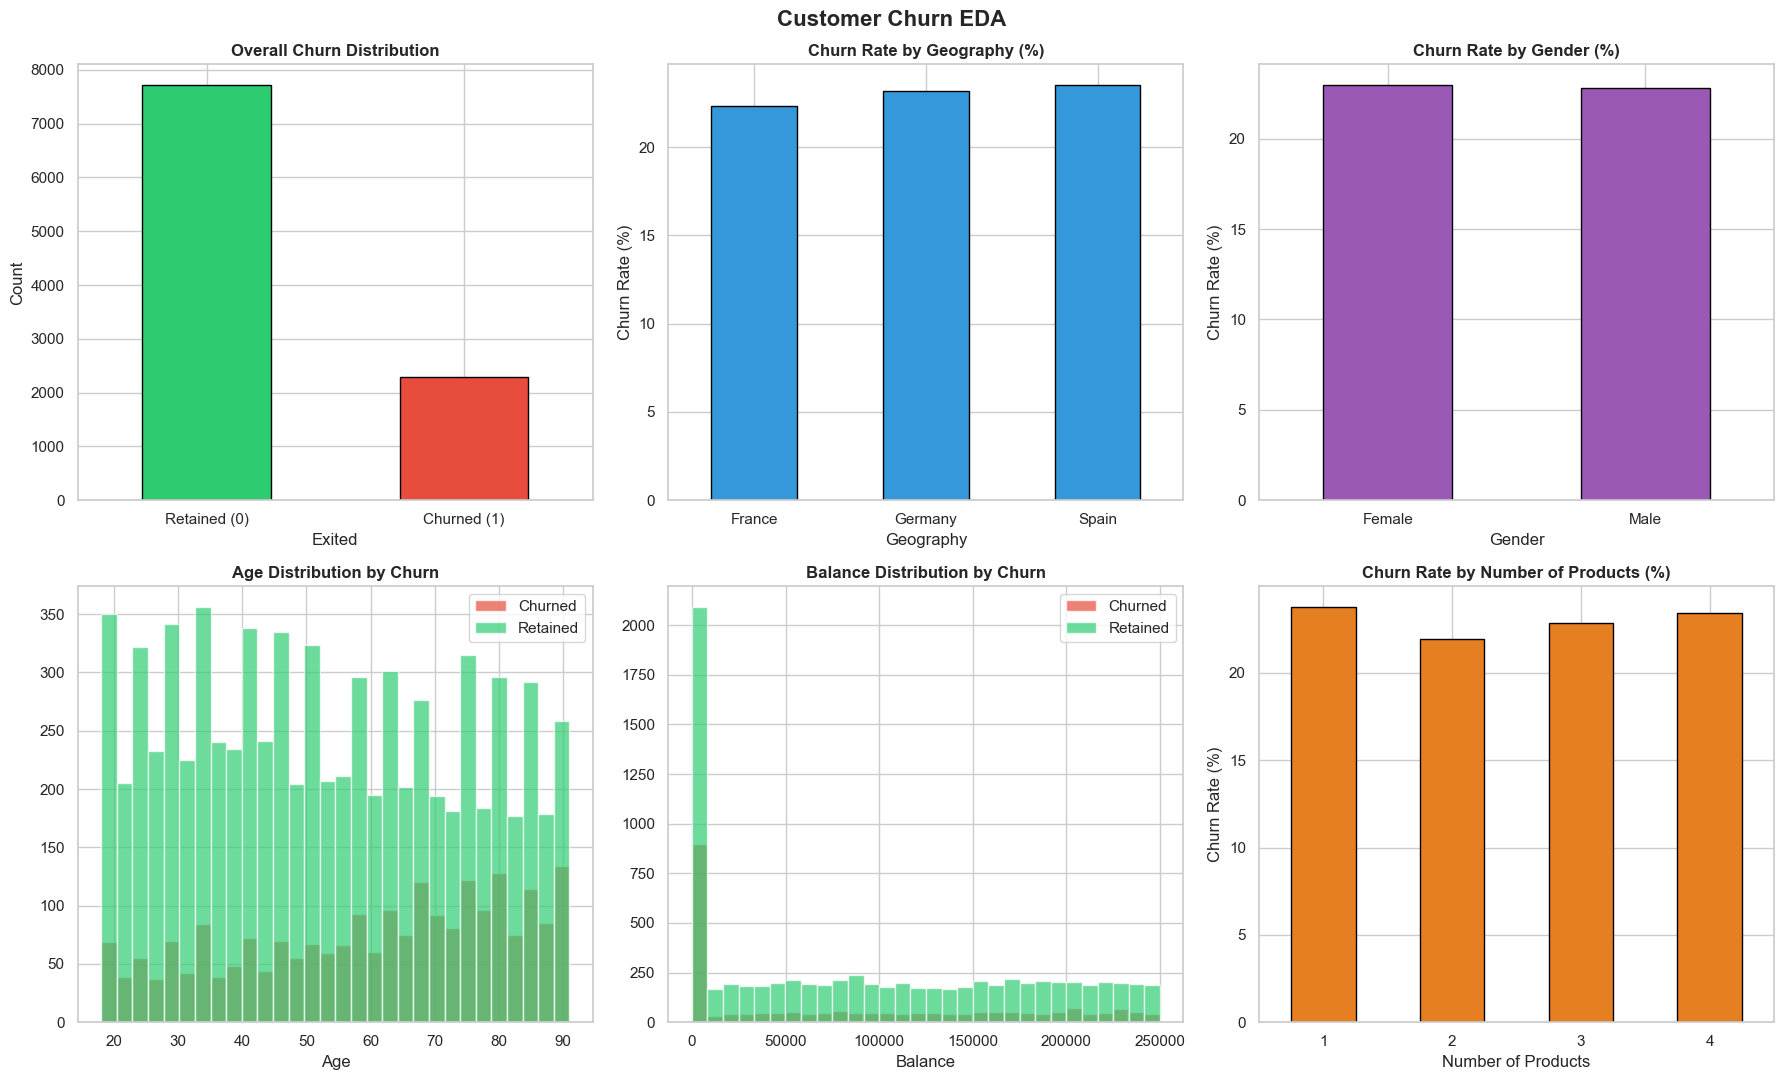

In [8]:
# Churn rate by key demographics
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Overall churn
df['Exited'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#2ECC71','#E74C3C'], edgecolor='black')
axes[0,0].set_title('Overall Churn Distribution', fontweight='bold')
axes[0,0].set_xticklabels(['Retained (0)','Churned (1)'], rotation=0)
axes[0,0].set_ylabel('Count')

# Churn by Geography
churn_geo = df.groupby('Geography')['Exited'].mean() * 100
churn_geo.plot(kind='bar', ax=axes[0,1], color='#3498DB', edgecolor='black')
axes[0,1].set_title('Churn Rate by Geography (%)', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(rotation=0)

# Churn by Gender
churn_gender = df.groupby('Gender')['Exited'].mean() * 100
churn_gender.plot(kind='bar', ax=axes[0,2], color='#9B59B6', edgecolor='black')
axes[0,2].set_title('Churn Rate by Gender (%)', fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)')
axes[0,2].tick_params(rotation=0)

# Age distribution by churn
df[df['Exited']==1]['Age'].hist(bins=30, ax=axes[1,0], alpha=0.7, label='Churned', color='#E74C3C')
df[df['Exited']==0]['Age'].hist(bins=30, ax=axes[1,0], alpha=0.7, label='Retained', color='#2ECC71')
axes[1,0].set_title('Age Distribution by Churn', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Balance distribution by churn
df[df['Exited']==1]['Balance'].hist(bins=30, ax=axes[1,1], alpha=0.7, label='Churned', color='#E74C3C')
df[df['Exited']==0]['Balance'].hist(bins=30, ax=axes[1,1], alpha=0.7, label='Retained', color='#2ECC71')
axes[1,1].set_title('Balance Distribution by Churn', fontweight='bold')
axes[1,1].set_xlabel('Balance')
axes[1,1].legend()

# Products count by churn
churn_prod = df.groupby('NumOfProducts')['Exited'].mean() * 100
churn_prod.plot(kind='bar', ax=axes[1,2], color='#E67E22', edgecolor='black')
axes[1,2].set_title('Churn Rate by Number of Products (%)', fontweight='bold')
axes[1,2].set_xlabel('Number of Products')
axes[1,2].set_ylabel('Churn Rate (%)')
axes[1,2].tick_params(rotation=0)

plt.suptitle('Customer Churn EDA', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()

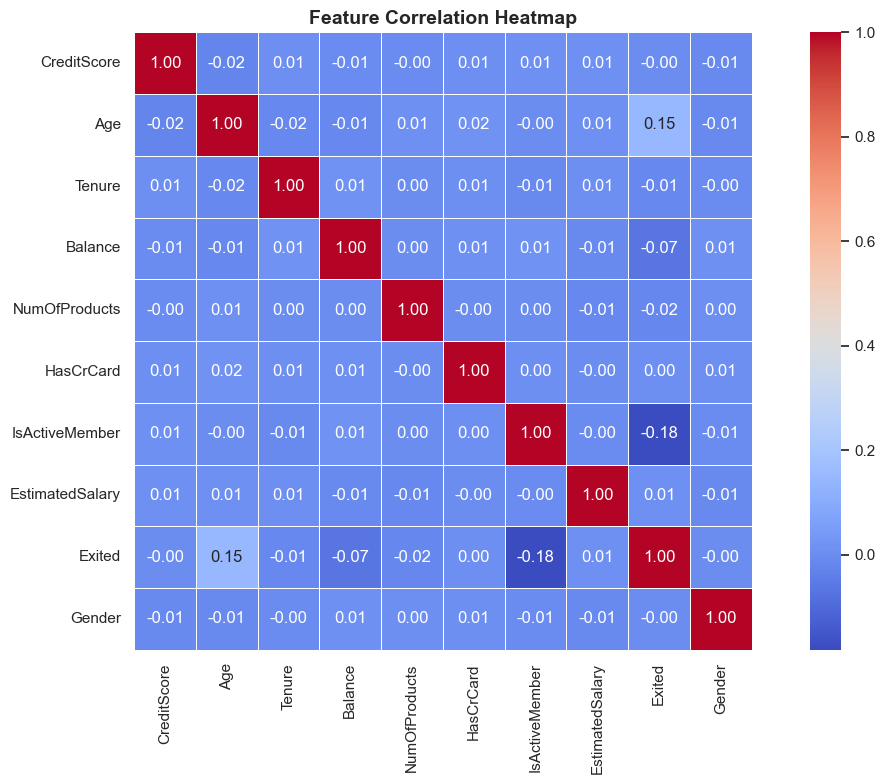

Observation: Age and Balance show the strongest correlation with churn.


In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
             'HasCrCard','IsActiveMember','EstimatedSalary','Exited','Gender']
corr = df_clean[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Age and Balance show the strongest correlation with churn.")

## 7. Model Training

In [10]:
# Features and Target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features: {X.shape[1]}")

Training samples: 8000
Testing samples:  2000
Features: 12


In [11]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy:       {rf_acc*100:.2f}%")

Logistic Regression Accuracy: 76.95%
Random Forest Accuracy:       76.65%


## 8. Model Evaluation

In [12]:
models_eval = {
    'Logistic Regression': (lr_pred, lr_acc),
    'Random Forest': (rf_pred, rf_acc)
}

for name, (pred, acc) in models_eval.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, pred, target_names=['Retained','Churned']))


  Logistic Regression
  Accuracy: 76.95%

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.77      1.00      0.87      1543
     Churned       0.25      0.00      0.01       457

    accuracy                           0.77      2000
   macro avg       0.51      0.50      0.44      2000
weighted avg       0.65      0.77      0.67      2000


  Random Forest
  Accuracy: 76.65%

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.77      0.99      0.87      1543
     Churned       0.32      0.02      0.04       457

    accuracy                           0.77      2000
   macro avg       0.55      0.50      0.45      2000
weighted avg       0.67      0.77      0.68      2000



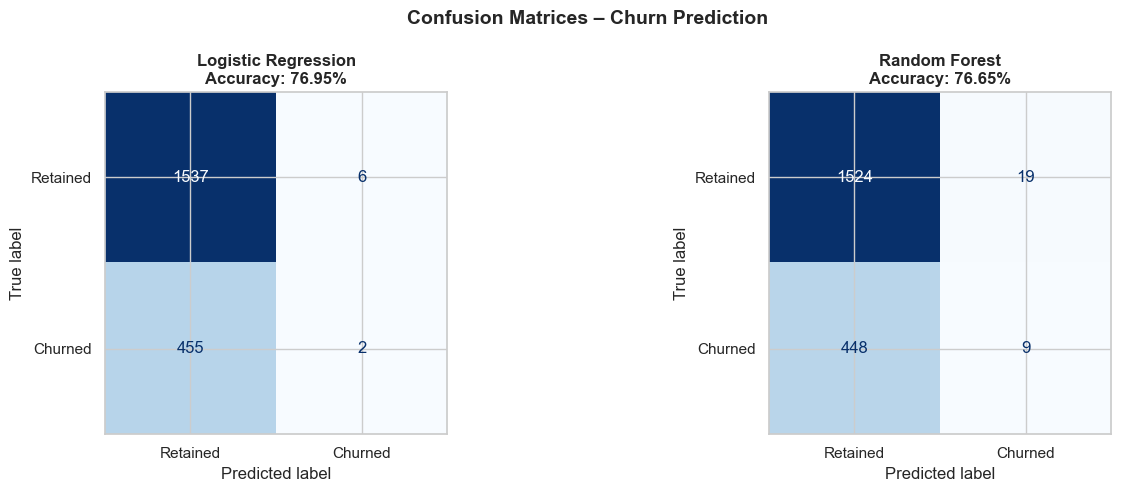

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, (pred, acc)) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
plt.suptitle('Confusion Matrices – Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance Analysis

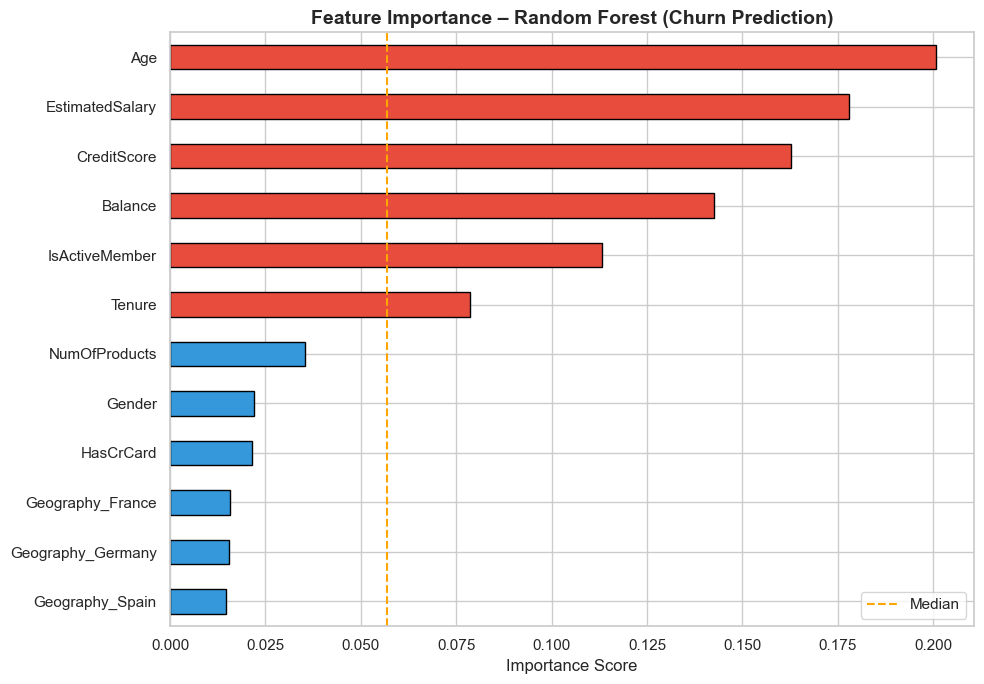

Top 5 Most Important Features:
Age                0.200693
EstimatedSalary    0.178074
CreditScore        0.162683
Balance            0.142561
IsActiveMember     0.113090
dtype: float64


In [14]:
# Random Forest Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#E74C3C' if imp > importances.median() else '#3498DB' for imp in importances]
importances.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Importance – Random Forest (Churn Prediction)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(importances.median(), color='orange', linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Most Important Features:")
print(importances.sort_values(ascending=False).head(5))

## 10. Conclusion

### Key Insights:

1. **Age is a Top Predictor**: Older customers churn more — middle-aged and senior customers show higher exit rates than younger ones.

2. **Balance Matters**: Customers with higher balances tend to churn more, possibly because they are wealthier and have more options.

3. **Geography Impact**: Germany has noticeably higher churn rates compared to France and Spain, suggesting regional factors at play.

4. **Active Members Stay**: IsActiveMember is one of the strongest features — inactive customers are far more likely to leave.

5. **Number of Products**: Customers with only 1 product churn more; those with 2 products have the lowest churn rate.

6. **Model Performance**: Random Forest outperforms Logistic Regression for this dataset due to its ability to capture non-linear relationships.

### Skills Applied:
- Categorical encoding (Label Encoding for Gender, One-Hot Encoding for Geography)
- Supervised classification with Logistic Regression and Random Forest
- Feature importance interpretation to understand churn drivers
- Confusion matrix and classification report for model evaluation
